In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

In [7]:
print("=" * 50)
print("     DECODELABS — PROJECT 2 PIPELINE        ")
print("=" * 50)

     DECODELABS — PROJECT 2 PIPELINE        


In [8]:
df = pd.read_csv('Iris.csv')

In [14]:
print(f"Total Rows : {df.shape[0]}")
print(f"Total Columns :{df.shape[1]}")
print(f"\nColumn Names:")
print(list(df.columns))

Total Rows : 150
Total Columns :6

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [10]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
print(f"Class Distribution:")
print(df['Species'].value_counts())

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [16]:
df.describe().round(2)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


In [17]:
print(f"Missing Values:")
print(df.isnull().sum())

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [19]:
df = df.drop(columns=['Id'])

In [18]:
#Separation of features (X) and label (y)
X = df[['SepalLengthCm', 'SepalWidthCm',
        'PetalLengthCm', 'PetalWidthCm']].values

In [20]:
# Iris-setosa=0, Iris-versicolor=1, Iris-virginica=2
le = LabelEncoder()
y = le.fit_transform(df['Species'])

class_names = le.classes_ 
short_names  = ['Setosa', 'Versicolor', 'Virginica']

print(f"\nEncoded Classes:")
for i, name in enumerate(class_names):
    print(f"  {i} → {name}")


Encoded Classes:
  0 → Iris-setosa
  1 → Iris-versicolor
  2 → Iris-virginica


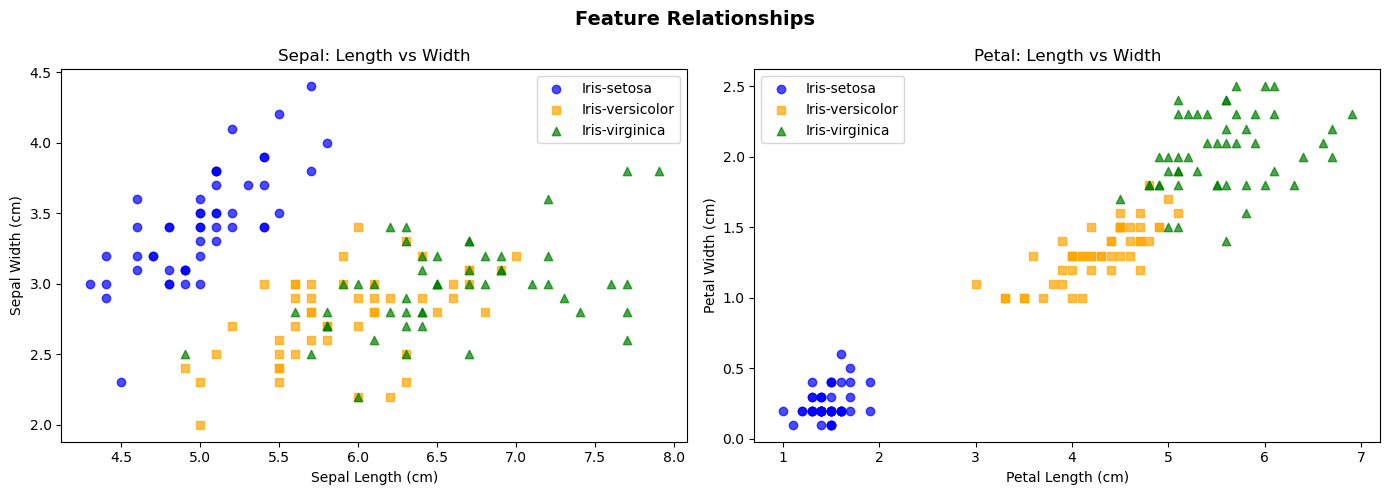

    Saved: feature_relationships.png


In [21]:
colors  = ['blue', 'orange', 'green']
markers = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, color, marker) in enumerate(zip(class_names, colors, markers)):
    mask = df['Species'] == label
    axes[0].scatter(
        df[mask]['SepalLengthCm'],
        df[mask]['SepalWidthCm'],
        label=label, color=color, marker=marker, alpha=0.7
    )
    axes[1].scatter(
        df[mask]['PetalLengthCm'],
        df[mask]['PetalWidthCm'],
        label=label, color=color, marker=marker, alpha=0.7
    )

axes[0].set_title('Sepal: Length vs Width')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].legend()

axes[1].set_title('Petal: Length vs Width')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()

plt.suptitle('Feature Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_relationships.png')
plt.show()
print("    Saved: feature_relationships.png")

In [22]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean BEFORE scaling: {X.mean(axis=0).round(2)}")
print(f"Mean AFTER  scaling: {X_scaled.mean(axis=0).round(2)}")
print(f"Std  AFTER  scaling: {X_scaled.std(axis=0).round(2)}")
print("Scaling complete — Mean=0, Variance=1 ✓")

Mean BEFORE scaling: [5.84 3.05 3.76 1.2 ]
Mean AFTER  scaling: [-0. -0.  0. -0.]
Std  AFTER  scaling: [1. 1. 1. 1.]
Scaling complete — Mean=0, Variance=1 ✓


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Total samples    : {len(y)}")
print(f"Training samples : {X_train.shape[0]} (80%)")
print(f"Testing samples  : {X_test.shape[0]}  (20%)")
print("Data shuffled to remove order bias ✓")

Total samples    : 150
Training samples : 120 (80%)
Testing samples  : 30  (20%)
Data shuffled to remove order bias ✓


K values tested : 1 to 20
Optimal K found : 2 (lowest error rate)


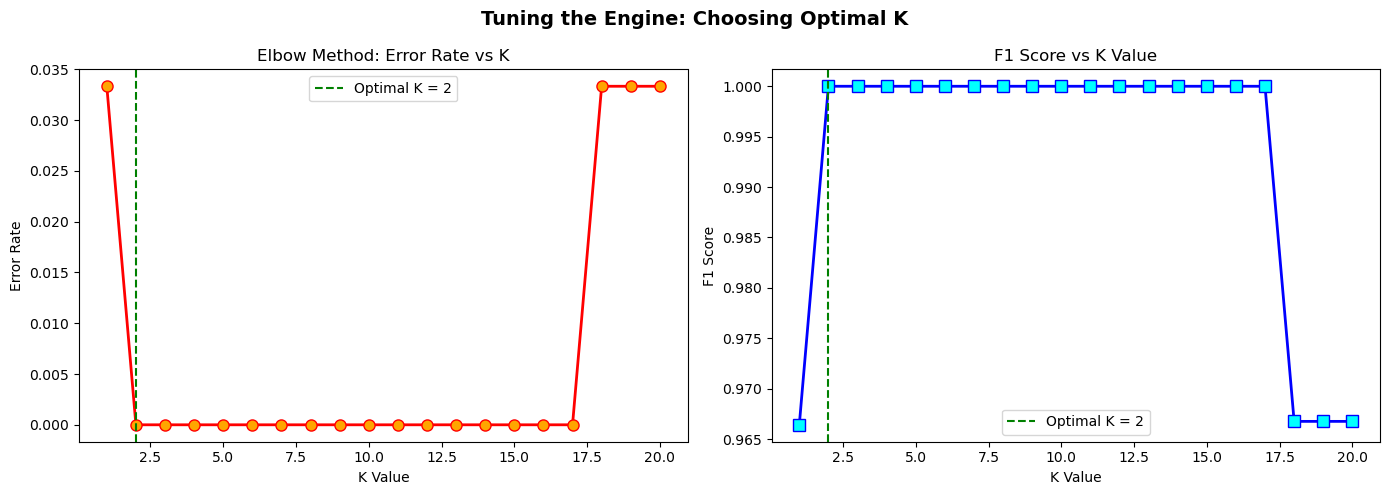

    Saved: elbow_method.png


In [25]:
k_range = range(1, 21)
error_rates = []
f1_scores_k = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    preds_temp = knn_temp.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds_temp))
    f1_scores_k.append(f1_score(y_test, preds_temp, average='weighted'))

best_k = list(k_range)[np.argmin(error_rates)]
print(f"K values tested : 1 to 20")
print(f"Optimal K found : {best_k} (lowest error rate)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, error_rates, color='red', marker='o',
             markerfacecolor='orange', markersize=8, linewidth=2)
axes[0].axvline(x=best_k, color='green', linestyle='--',
                label=f'Optimal K = {best_k}')
axes[0].set_title('Elbow Method: Error Rate vs K')
axes[0].set_xlabel('K Value')
axes[0].set_ylabel('Error Rate')
axes[0].legend()

axes[1].plot(k_range, f1_scores_k, color='blue', marker='s',
             markerfacecolor='cyan', markersize=8, linewidth=2)
axes[1].axvline(x=best_k, color='green', linestyle='--',
                label=f'Optimal K = {best_k}')
axes[1].set_title('F1 Score vs K Value')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('F1 Score')
axes[1].legend()

plt.suptitle('Tuning the Engine: Choosing Optimal K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_method.png')
plt.show()
print("    Saved: elbow_method.png")

In [27]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f"Algorithm : K-Nearest Neighbors")
print(f"K Value   : {best_k} (auto-selected via Elbow Method)")
print(f"Model training complete ✓")

Algorithm : K-Nearest Neighbors
K Value   : 2 (auto-selected via Elbow Method)
Model training complete ✓


In [30]:
accuracy = accuracy_score(y_test, predictions)
f1       = f1_score(y_test, predictions, average='weighted')
cm       = confusion_matrix(y_test, predictions)
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"F1 Score : {f1:.4f}")

Accuracy : 100.00%
F1 Score : 1.0000


In [35]:
print(f"===CLASSIFICATION REPORT===")
print(classification_report(
    y_test, predictions,
    target_names=short_names
))

===CLASSIFICATION REPORT===
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [37]:
print(f"=== CONFUSION MATRIX ===")
print(cm)

=== CONFUSION MATRIX ===
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


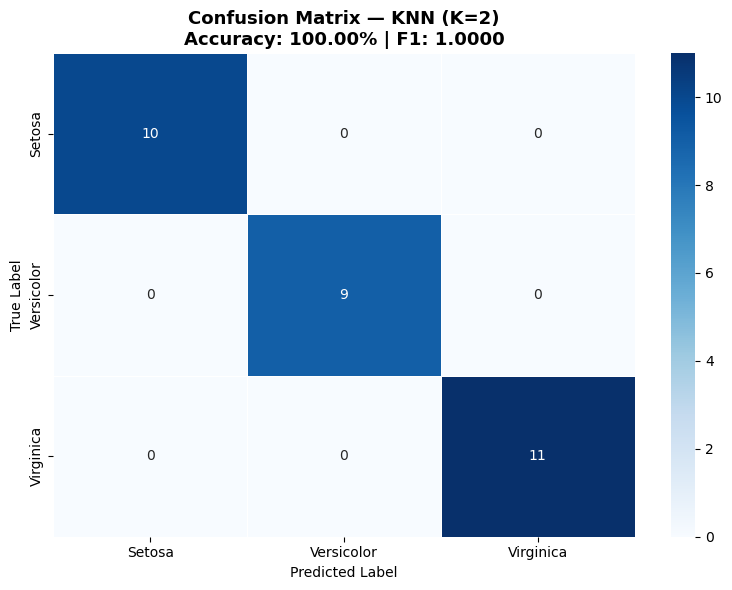

    Saved: confusion_matrix.png


In [38]:
# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.5
)
plt.title(
    f'Confusion Matrix — KNN (K={best_k})\n'
    f'Accuracy: {accuracy*100:.2f}% | F1: {f1:.4f}',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("    Saved: confusion_matrix.png")

In [39]:
#Test Scenario
new_flowers = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.2, 2.9, 4.3, 1.3],
    [7.3, 3.0, 6.3, 1.8],
])

# Scaling
new_flowers_scaled = scaler.transform(new_flowers)

new_predictions  = model.predict(new_flowers_scaled)
new_probabilities = model.predict_proba(new_flowers_scaled)

print(f"\n{'Flower':<10} {'Sepal L':<10} {'Sepal W':<10} "
      f"{'Petal L':<10} {'Petal W':<10} {'Predicted':<15} {'Confidence'}")
print("-" * 78)

for i, (flower, pred, proba) in enumerate(
    zip(new_flowers, new_predictions, new_probabilities)
):
    confidence = max(proba) * 100
    species    = short_names[pred]
    print(f"Flower {i+1:<4} {flower[0]:<10} {flower[1]:<10} "
          f"{flower[2]:<10} {flower[3]:<10} {species:<15} {confidence:.1f}%")


Flower     Sepal L    Sepal W    Petal L    Petal W    Predicted       Confidence
------------------------------------------------------------------------------
Flower 1    5.1        3.5        1.4        0.2        Setosa          100.0%
Flower 2    6.2        2.9        4.3        1.3        Versicolor      100.0%
Flower 3    7.3        3.0        6.3        1.8        Virginica       100.0%


In [40]:
print("\n" + "=" * 50)
print("           PIPELINE COMPLETE SUMMARY          ")
print("=" * 50)
print(f"  Dataset        : Iris.csv (150 samples, 3 classes)")
print(f"  Algorithm      : K-Nearest Neighbors")
print(f"  Optimal K      : {best_k} (Elbow Method)")
print(f"  Training Size  : {X_train.shape[0]} samples (80%)")
print(f"  Testing Size   : {X_test.shape[0]} samples  (20%)")
print(f"  Accuracy       : {accuracy * 100:.2f}%")
print(f"  F1 Score       : {f1:.4f}")
print(f"  Charts Saved   : 3 files")


           PIPELINE COMPLETE SUMMARY          
  Dataset        : Iris.csv (150 samples, 3 classes)
  Algorithm      : K-Nearest Neighbors
  Optimal K      : 2 (Elbow Method)
  Training Size  : 120 samples (80%)
  Testing Size   : 30 samples  (20%)
  Accuracy       : 100.00%
  F1 Score       : 1.0000
  Charts Saved   : 3 files
